In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [0]:
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

appointments_data = [
    (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
    (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
    (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
    (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
    (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
    (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
    (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
    (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
    (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
    (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
    (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
    (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
    (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
    (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
    (1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = ["appointment_id", "city", "department", "hospital", "consultation_fee", "status"]
df = spark.createDataFrame(appointments_data, columns)

In [0]:
pdf = df.toPandas()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344135-1383751989:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf, x="city", palette="muted")


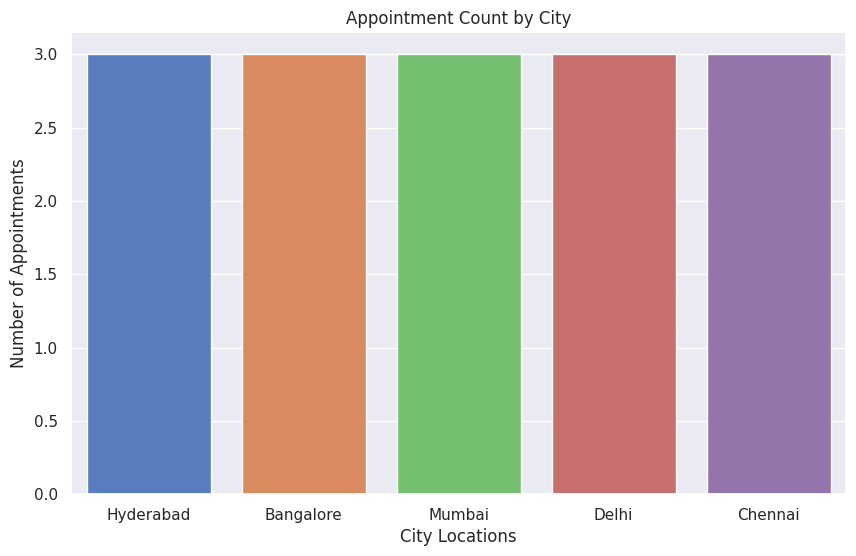

In [0]:
# 1. Bar Chart: Appointment Count by City
# -------------------------------------------------------------
plt.figure()
sns.countplot(data=pdf, x="city", palette="muted")
plt.title("Appointment Count by City")
plt.xlabel("City Locations")
plt.ylabel("Number of Appointments")
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344134-3202752460:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf, x="department", palette="Set2")


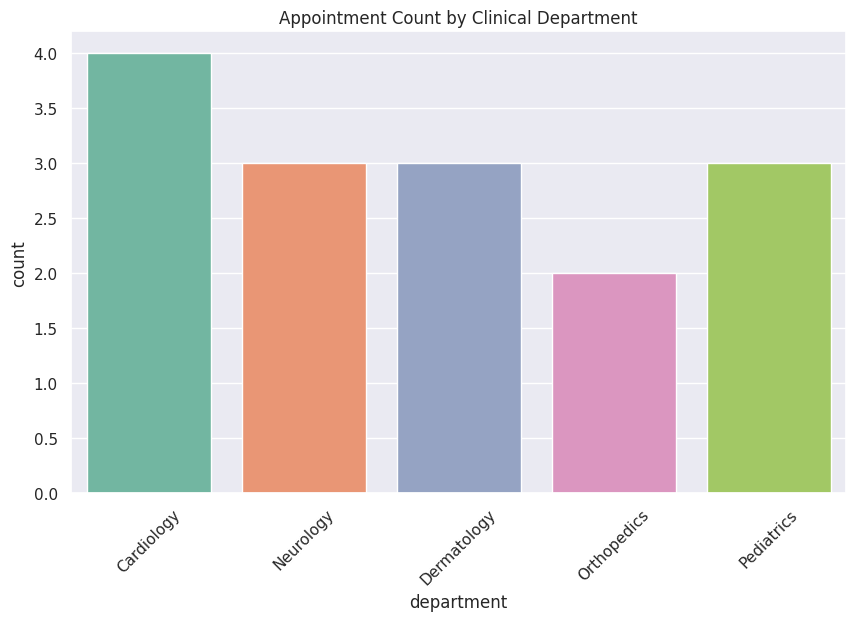

In [0]:
# 2. Bar Chart: Appointment Count by Department
# -------------------------------------------------------------
plt.figure()
sns.countplot(data=pdf, x="department", palette="Set2")
plt.title("Appointment Count by Clinical Department")
plt.xticks(rotation=45) # 11. Rotate labels
plt.show()

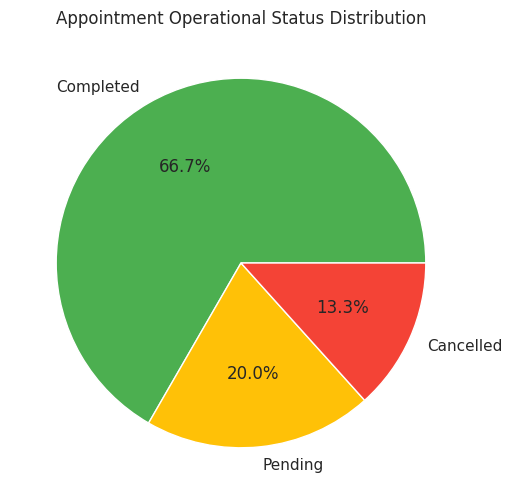

In [0]:
# 3. Pie Chart: Status Distribution
# -------------------------------------------------------------
plt.figure()
status_counts = pdf["status"].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=["#4CAF50", "#FFC107", "#F44336"])
plt.title("Appointment Operational Status Distribution")
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344132-904171170:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_rev, x="city", y="consultation_fee", palette="viridis")


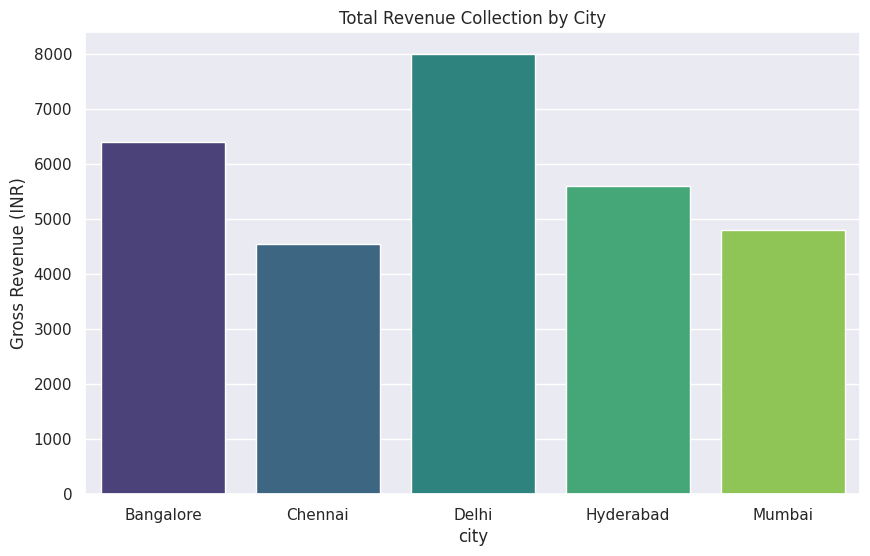

In [0]:
# 4. Bar Chart: Revenue by City (Aggregate Sum)
# -------------------------------------------------------------
plt.figure()
city_rev = pdf.groupby("city")["consultation_fee"].sum().reset_index()
sns.barplot(data=city_rev, x="city", y="consultation_fee", palette="viridis")
plt.title("Total Revenue Collection by City")
plt.ylabel("Gross Revenue (INR)")
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344131-1829806465:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_rev, x="department", y="consultation_fee", palette="magma")


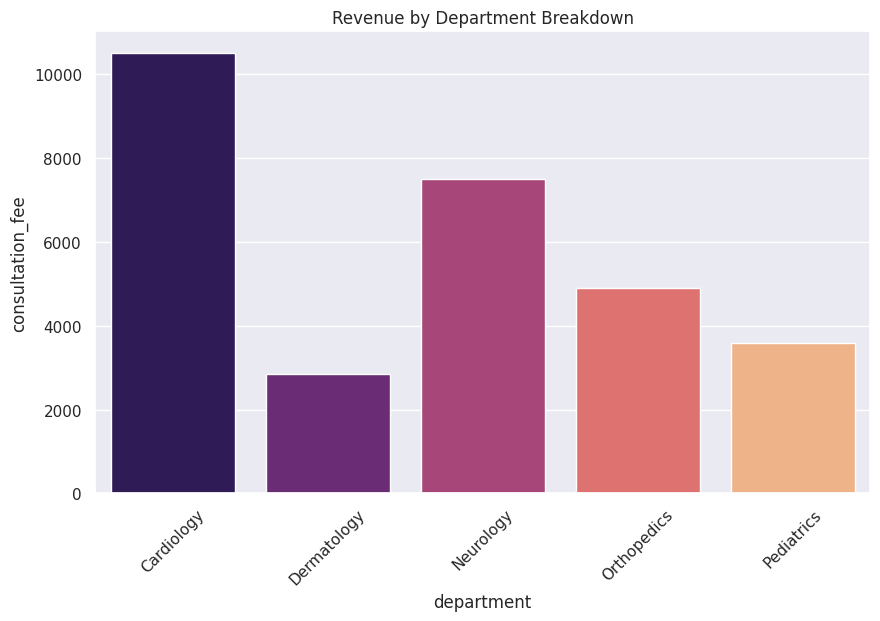

In [0]:
# 5. Bar Chart: Revenue by Department
# -------------------------------------------------------------
plt.figure()
dept_rev = pdf.groupby("department")["consultation_fee"].sum().reset_index()
sns.barplot(data=dept_rev, x="department", y="consultation_fee", palette="magma")
plt.title("Revenue by Department Breakdown")
plt.xticks(rotation=45)
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344130-3740507174:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hosp_rev, y="hospital", x="consultation_fee", palette="crest", orient="h")


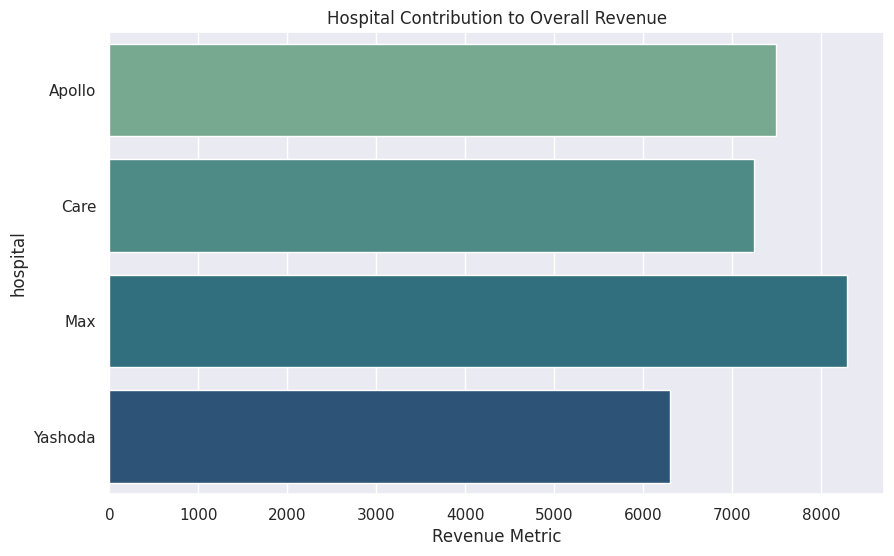

In [0]:
# 6. Horizontal Bar Chart: Revenue by Hospital
# -------------------------------------------------------------
plt.figure()
hosp_rev = pdf.groupby("hospital")["consultation_fee"].sum().reset_index()
sns.barplot(data=hosp_rev, y="hospital", x="consultation_fee", palette="crest", orient="h")
plt.title("Hospital Contribution to Overall Revenue")
plt.xlabel("Revenue Metric")
plt.show()

<Figure size 1000x600 with 0 Axes>

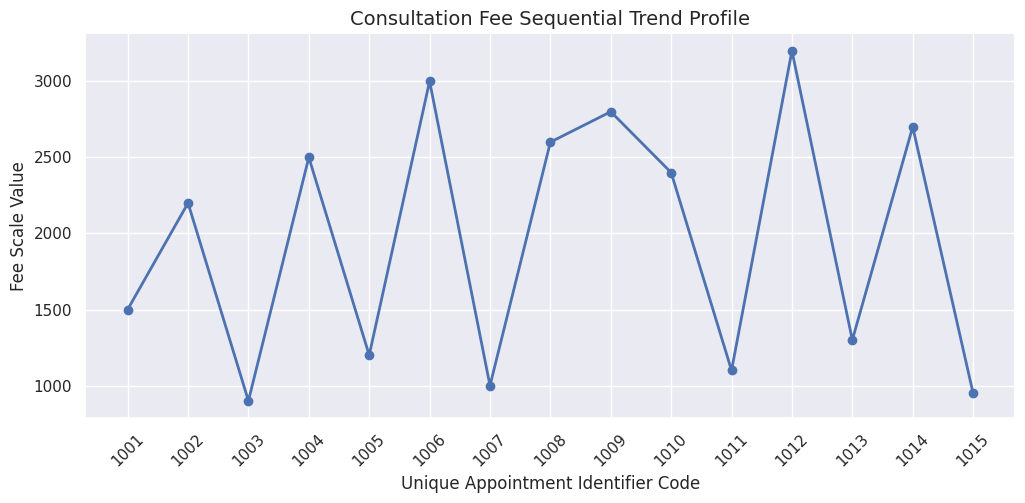

In [0]:
# 7. Line Chart: Consultation Fee Trend
# -------------------------------------------------------------
plt.figure()
# 12, 13, 14, 15: Demonstrating layout modifications explicitly
plt.figure(figsize=(12, 5)) # Increase figure size
plt.plot(pdf["appointment_id"].astype(str), pdf["consultation_fee"], marker='o', color='b', linestyle='-', linewidth=2)
plt.title("Consultation Fee Sequential Trend Profile", fontsize=14)
plt.xlabel("Unique Appointment Identifier Code", fontsize=12)
plt.ylabel("Fee Scale Value", fontsize=12)
plt.xticks(rotation=45)
plt.show()

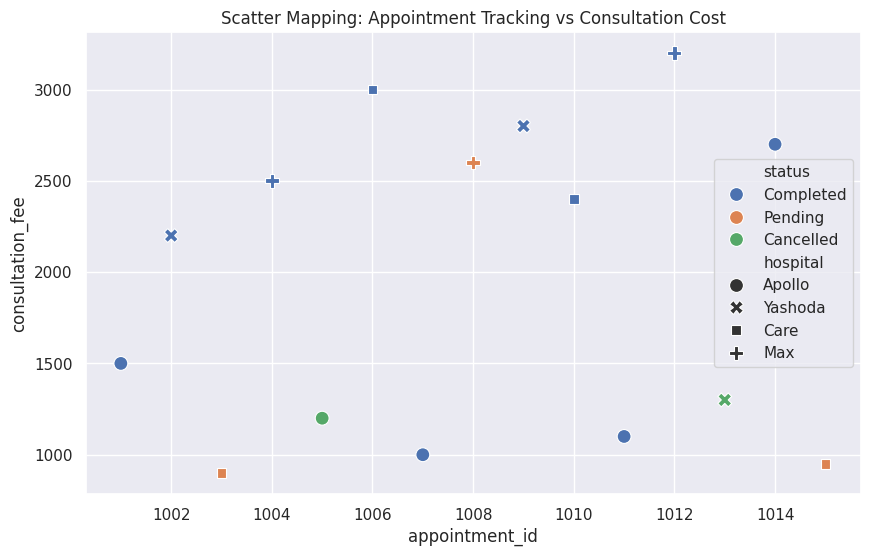

In [0]:
# 8. Scatter Plot: Appointment ID vs Fee
# -------------------------------------------------------------
plt.figure()
sns.scatterplot(data=pdf, x="appointment_id", y="consultation_fee", hue="status", style="hospital", s=100)
plt.title("Scatter Mapping: Appointment Tracking vs Consultation Cost")
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344148-2243365393:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=completed_pdf, x="city", y="consultation_fee", estimator=sum, errorbar=None, palette="rocket")


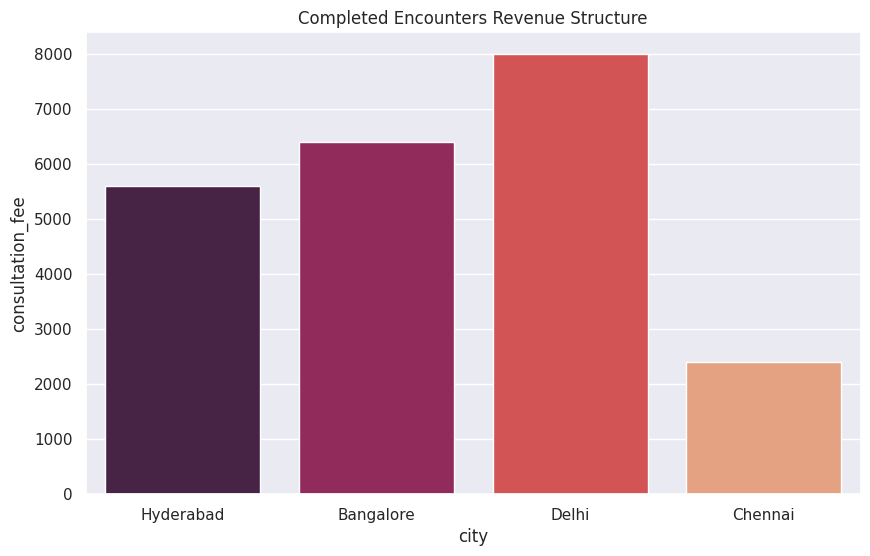

In [0]:
# 9. Chart Only for Completed Appointments
# -------------------------------------------------------------
plt.figure()
completed_pdf = pdf[pdf["status"] == "Completed"]
sns.barplot(data=completed_pdf, x="city", y="consultation_fee", estimator=sum, errorbar=None, palette="rocket")
plt.title("Completed Encounters Revenue Structure")
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344147-582120030:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_pdf, x="hospital", y="consultation_fee", estimator=sum, errorbar=None, palette="cubehelix")


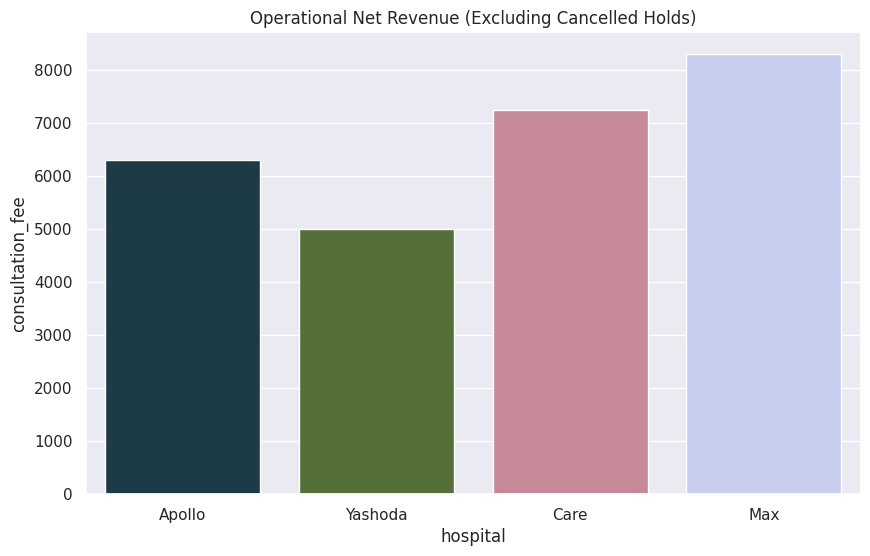

In [0]:
# 10. Revenue Chart after Excluding Cancelled Appointments
# -------------------------------------------------------------
plt.figure()
active_pdf = pdf[pdf["status"] != "Cancelled"]
sns.barplot(data=active_pdf, x="hospital", y="consultation_fee", estimator=sum, errorbar=None, palette="cubehelix")
plt.title("Operational Net Revenue (Excluding Cancelled Holds)")
plt.show()

In [0]:
print("--- 16. Top 3 Cities by Revenue ---")
print(city_rev.sort_values(by="consultation_fee", ascending=False).head(3).to_string(index=False))

--- 16. Top 3 Cities by Revenue ---
     city  consultation_fee
    Delhi              8000
Bangalore              6400
Hyderabad              5600


In [0]:
print("\n--- 17. Top 3 Departments by Revenue ---")
print(dept_rev.sort_values(by="consultation_fee", ascending=False).head(3).to_string(index=False))


--- 17. Top 3 Departments by Revenue ---
 department  consultation_fee
 Cardiology             10500
  Neurology              7500
Orthopedics              4900


In [0]:
print("\n--- 18. Lowest Revenue Hospital ---")
print(hosp_rev.sort_values(by="consultation_fee", ascending=True).head(1).to_string(index=False))


--- 18. Lowest Revenue Hospital ---
hospital  consultation_fee
 Yashoda              6300


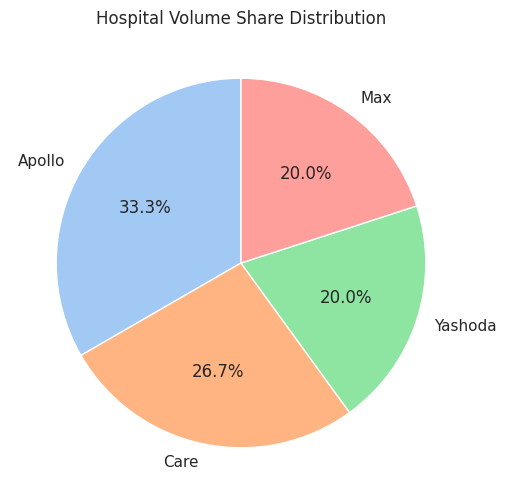

In [0]:
plt.figure()
hosp_shares = pdf["hospital"].value_counts()
plt.pie(hosp_shares, labels=hosp_shares.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Hospital Volume Share Distribution")
plt.show()

/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344142-610446117:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,0], data=city_rev, x="city", y="consultation_fee", palette="Blues_r")
/home/spark-3207f979-b7d8-438b-8275-5e/.ipykernel/2088/command-8891456145344142-610446117:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1,0], data=dept_rev, x="department", y="consultation_fee", palette="Purples_r")


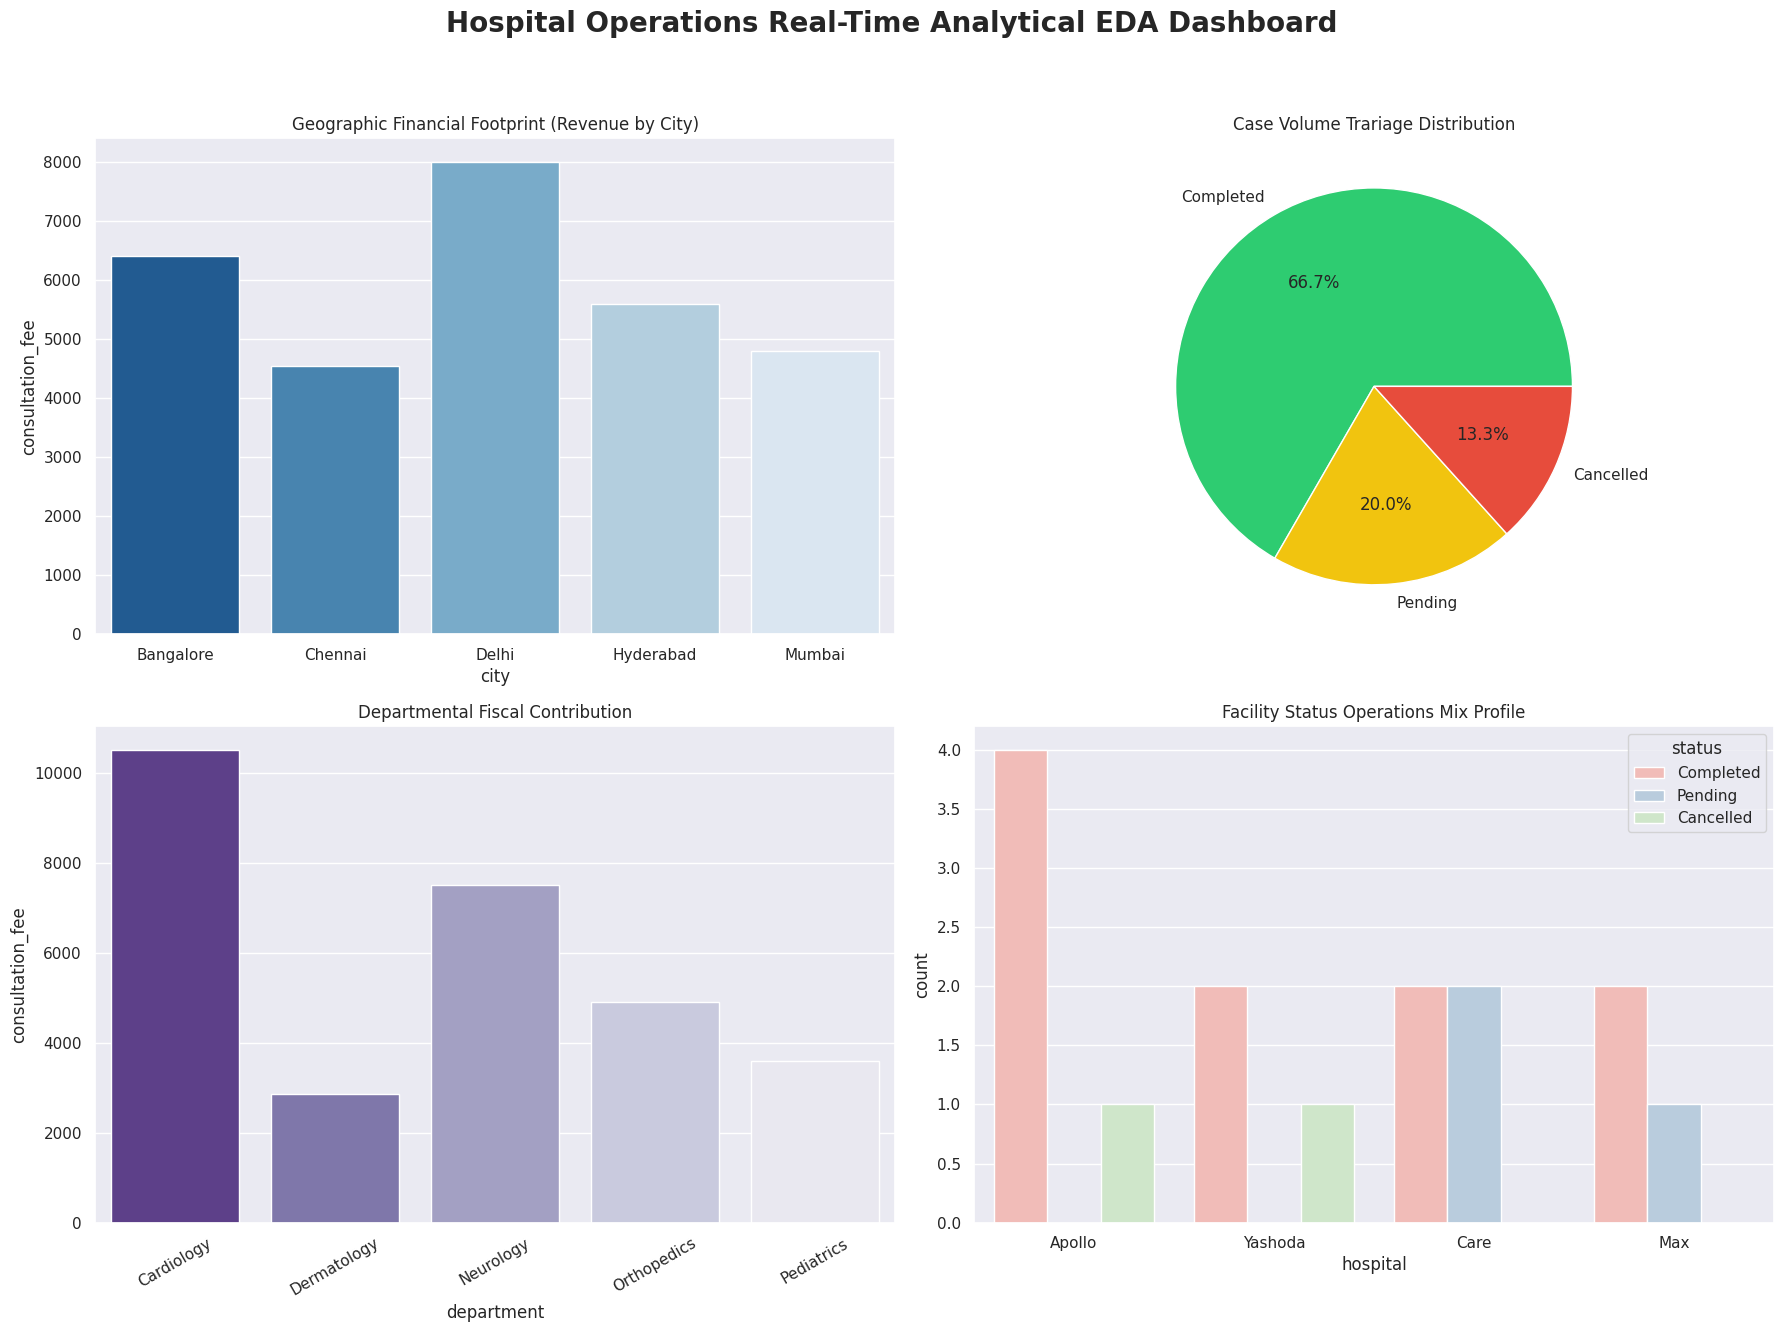

In [0]:
# Setup a 2x2 multi-plot canvas structure for dashboarding
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Hospital Operations Real-Time Analytical EDA Dashboard", fontsize=20, weight="bold")

# Panel A: Revenue Source Mapping
sns.barplot(ax=axes[0,0], data=city_rev, x="city", y="consultation_fee", palette="Blues_r")
axes[0,0].set_title("Geographic Financial Footprint (Revenue by City)", fontsize=12)

# Panel B: Volume Distribution
axes[0,1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=["#2ecc71", "#f1c40f", "#e74c3c"])
axes[0,1].set_title("Case Volume Trariage Distribution", fontsize=12)

# Panel C: Functional Lines
sns.barplot(ax=axes[1,0], data=dept_rev, x="department", y="consultation_fee", palette="Purples_r")
axes[1,0].set_title("Departmental Fiscal Contribution", fontsize=12)
axes[1,0].tick_params(axis='x', rotation=30)

# Panel D: Hospital Breakdown
sns.countplot(ax=axes[1,1], data=pdf, x="hospital", hue="status", palette="Pastel1")
axes[1,1].set_title("Facility Status Operations Mix Profile", fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()